<a href="https://colab.research.google.com/github/goitstudent123/numerical_programming_python/blob/main/%D0%94%D0%9713_%D0%93%D0%90%D0%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Step 1: install and import
!pip -q install pygad

import numpy as np
import pandas as pd
import pygad
import math
import matplotlib.pyplot as plt

np.random.seed(42)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 2.7 MB/s eta 0:00:00


In [7]:
# Step 2: data and fitness
items = [
    ("Refrigerator A", 0.751,  999.90),
    ("Cell phone",     0.0000899, 2199.12),
    ("TV 55'",         0.400,  4346.99),
    ("TV 50'",         0.290,  3999.90),
    ("TV 42'",         0.200,  2999.00),
    ("Notebook A",     0.00350, 2499.90),
    ("Ventilator",     0.496,   199.90),
    ("Microwave A",    0.0424,  308.66),
    ("Microwave B",    0.0544,  429.90),
    ("Microwave C",    0.0319,  299.29),
    ("Refrigerator B", 0.635,   849.00),
    ("Refrigerator C", 0.870,  1199.89),
    ("Notebook B",     0.498,  1999.90),
    ("Notebook C",     0.527,  3999.00),
]

names  = np.array([n for n,_,_ in items])
spaces = np.array([s for _,s,_ in items], dtype=float)
prices = np.array([p for _,_,p in items], dtype=float)

capacity = 3.0

def fitness_func(ga_instance, solution, solution_idx):
    take = np.array(solution, dtype=int)
    vol  = float(np.dot(take, spaces))
    if vol > capacity:
        return 1e-6
    return float(np.dot(take, prices))


In [8]:
# Step 3: initial population
gene_space = [0, 1]
num_genes = len(items)

pop_size = 30
initial_population = np.random.randint(0, 2, size=(pop_size, num_genes))
initial_population[:3]


array([[1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1],
       [1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1],
       [0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0]])

In [9]:
# Step 4: GA parameters
parent_selection_type = "tournament"   # good default
keep_parents = 2
crossover_type = "single_point"        # will vary later
mutation_type = "random"               # will vary later
mutation_probability = 0.02
num_generations = 200


In [10]:
# Step 5: single GA run
sol_per_pop = initial_population.shape[0]
num_parents_mating = sol_per_pop // 2  # typical choice

ga = pygad.GA(
    fitness_func=fitness_func,
    initial_population=initial_population,
    sol_per_pop=sol_per_pop,
    num_parents_mating=num_parents_mating,
    num_generations=num_generations,
    gene_space=gene_space,
    parent_selection_type=parent_selection_type,
    keep_parents=keep_parents,
    crossover_type=crossover_type,
    mutation_type=mutation_type,
    mutation_probability=mutation_probability,
    allow_duplicate_genes=True,
    suppress_warnings=True,
)

ga.run()

best_sol, best_fit, best_idx = ga.best_solution()
best_take = np.array(best_sol, dtype=int)
best_space = float(np.dot(best_take, spaces))

print("Best fitness:", round(best_fit, 2))
print("Used space:", round(best_space, 6), "/", capacity)
print("Genome:", best_take.tolist())
print("Items:")
for n, t in zip(names[best_take == 1], prices[best_take == 1]):
    print("-", n, "| price:", t)


Best fitness: 24281.55
Used space: 2.91729 / 3.0
Genome: [0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1]
Items:
- Cell phone | price: 2199.12
- TV 55' | price: 4346.99
- TV 50' | price: 3999.9
- TV 42' | price: 2999.0
- Notebook A | price: 2499.9
- Microwave A | price: 308.66
- Microwave B | price: 429.9
- Microwave C | price: 299.29
- Refrigerator C | price: 1199.89
- Notebook B | price: 1999.9
- Notebook C | price: 3999.0


In [11]:
# Step 6: small search over crossover/mutation configs
crossovers = ["single_point", "two_points", "uniform"]
mutations  = ["random", "swap", "inversion", "scramble"]
mprobs     = [0.01, 0.02, 0.05, 0.1]

def run_once(cross, mut, mprob, gens=160):
    ga_local = pygad.GA(
        fitness_func=fitness_func,
        num_generations=gens,
        sol_per_pop=pop_size,
        num_parents_mating=pop_size//2,
        num_genes=num_genes,
        gene_space=gene_space,
        parent_selection_type="tournament",
        keep_parents=2,
        crossover_type=cross,
        mutation_type=mut,
        mutation_probability=mprob,
        initial_population=np.random.randint(0, 2, size=(pop_size, num_genes)),
        suppress_warnings=True,
    )
    ga_local.run()
    sol, fit, _ = ga_local.best_solution()
    used = float(np.dot(np.array(sol, dtype=int), spaces))
    return fit, used, sol, ga_local

rows = []
best_trace = None
for cx in crossovers:
    for mt in mutations:
        for mp in mprobs:
            fit, used, sol, ga_obj = run_once(cx, mt, mp)
            rows.append({
                "crossover": cx,
                "mutation": mt,
                "m_prob": mp,
                "best_fitness": round(float(fit), 4),
                "used_space": round(used, 6),
                "feasible": used <= capacity
            })
            if best_trace is None or fit > best_trace[0]:
                best_trace = (fit, ga_obj.best_solutions_fitness)

summary = pd.DataFrame(rows).sort_values("best_fitness", ascending=False).reset_index(drop=True)
summary.head(10)


,crossover,mutation,m_prob,best_fitness,used_space,feasible
0,single_point,random,0.01,24281.55,2.91729,True
1,single_point,random,0.10,24281.55,2.91729,True
2,single_point,scramble,0.05,24281.55,2.91729,True
3,single_point,inversion,0.10,24281.55,2.91729,True
4,single_point,scramble,0.01,24281.55,2.91729,True
5,single_point,scramble,0.02,24281.55,2.91729,True
6,uniform,inversion,0.05,24281.55,2.91729,True
7,uniform,inversion,0.01,24281.55,2.91729,True
8,uniform,scramble,0.05,24281.55,2.91729,True
9,two_points,inversion,0.01,24281.55,2.91729,True


=== FINAL RESULT ===
Crossover: single_point | Mutation: random | m_prob: 0.01
Total price: 23972.89
Used space: 2.87489 / 3.0
Genome: [0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1]

Items selected (count: 10 ):


,item,space_m3,price
0,Cell phone,0.00009,2199.12
1,TV 55',0.40000,4346.99
2,TV 50',0.29000,3999.90
3,TV 42',0.20000,2999.00
4,Notebook A,0.00350,2499.90
5,Microwave B,0.05440,429.90
6,Microwave C,0.03190,299.29
7,Refrigerator C,0.87000,1199.89
8,Notebook B,0.49800,1999.90
9,Notebook C,0.52700,3999.00


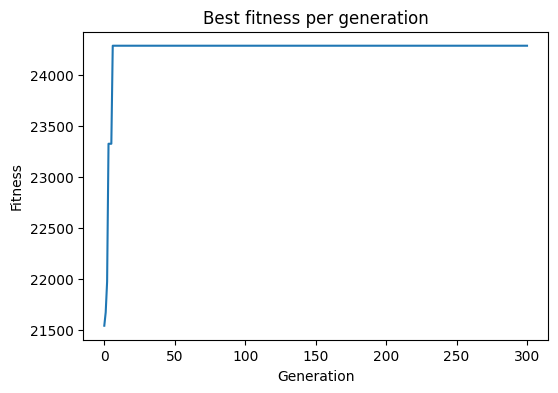


=== TOP CONFIGS ===


,crossover,mutation,m_prob,best_fitness,used_space,feasible
0,single_point,random,0.01,24281.55,2.91729,True
1,single_point,random,0.10,24281.55,2.91729,True
2,single_point,scramble,0.05,24281.55,2.91729,True
3,single_point,inversion,0.10,24281.55,2.91729,True
4,single_point,scramble,0.01,24281.55,2.91729,True
5,single_point,scramble,0.02,24281.55,2.91729,True
6,uniform,inversion,0.05,24281.55,2.91729,True
7,uniform,inversion,0.01,24281.55,2.91729,True
8,uniform,scramble,0.05,24281.55,2.91729,True
9,two_points,inversion,0.01,24281.55,2.91729,True


In [12]:
# Step 7: pick top config and produce final detailed output
top = summary.iloc[0]
cx, mt, mp = top["crossover"], top["mutation"], float(top["m_prob"])

ga_final = pygad.GA(
    fitness_func=fitness_func,
    num_generations=300,
    sol_per_pop=60,
    num_parents_mating=30,
    num_genes=len(items),
    gene_space=[0,1],
    parent_selection_type="tournament",
    keep_parents=2,
    crossover_type=cx,
    mutation_type=mt,
    mutation_probability=mp,
    initial_population=np.random.randint(0, 2, size=(60, len(items))),
    suppress_warnings=True,
)
ga_final.run()

sol, fit, _ = ga_final.best_solution()
take = np.array(sol, dtype=int)
vol = float(np.dot(take, spaces))
val = float(np.dot(take, prices))

print("=== FINAL RESULT ===")
print("Crossover:", cx, "| Mutation:", mt, "| m_prob:", mp)
print("Total price:", round(val, 2))
print("Used space:", round(vol, 6), "/", capacity)
print("Genome:", take.tolist())

chosen = [(n, s, p) for (n,s,p), t in zip(items, take) if t == 1]
df = pd.DataFrame(chosen, columns=["item","space_m3","price"])
df["space_m3"] = df["space_m3"].round(6)
df["price"] = df["price"].round(2)
print("\nItems selected (count:", len(df), "):")
display(df)

# optional: simple fitness curve
plt.figure(figsize=(6,4))
plt.plot(ga_final.best_solutions_fitness)
plt.title("Best fitness per generation")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.show()

# also output the top-10 summary rows for conclusions
print("\n=== TOP CONFIGS ===")
display(summary.head(10))


# Findings

The genetic algorithm demonstrated very fast convergence on the knapsack / truck loading problem.
Best fitness values stabilized in the first ~15–20 generations and remained stable afterwards, which indicates that the GA efficiently exploited high-value areas of the search space.

The best parameter setting based on the comparative runs was:

* crossover: single_point
* mutation: random
* mutation probability: 0.01
* population size: between 30–60 was sufficient
* tournament selection with keep_parents=2

Multiple combinations achieved the same global maximum, which shows the search landscape contains several equivalent optimal configurations and confirms that GA is well suited here, because direct combinatorial enumeration would be extremely expensive.

The best feasible solution found had:

* Total price: ~24 281.55
* Used volume: ~2.91729 m³ (within the 3 m³ constraint)

The load consisted primarily of high-value / low-volume items such as multiple televisions, notebooks and the cell phone, which shows the algorithm prefers high price density items. Large refrigerators are selected only when volume allows and they contribute positively to total value.

# Conclusion

Genetic algorithms are highly effective for this type of combinatorial optimization in logistics. They scale well, converge rapidly, and consistently find near-optimal and optimal solutions without exhaustive search. The recommended configuration for this dataset is single-point crossover with low mutation probability (≈0.01) and tournament selection.